In [16]:
from pathlib import Path
import sys
import importlib
import os

import json
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
from IPython.display import display

# Notebook location expected:
NB_DIR = Path.cwd()
OCGM_DIR = NB_DIR.parent
PROJECT_DIR = OCGM_DIR.parent

for path in [PROJECT_DIR, OCGM_DIR / "scripts"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import theme.plot_theme as ptheme
import ocean_analysis as oa

# Reload during notebook development
importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(oa)


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


<module 'ocean_analysis' from 'c:\\Users\\Jelle Gortemaker\\Documents\\Thesis\\OGCM\\scripts\\ocean_analysis.py'>

Red box lat range: 20.00 to 45.00
Red box lon range: -155.00 to -130.00


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


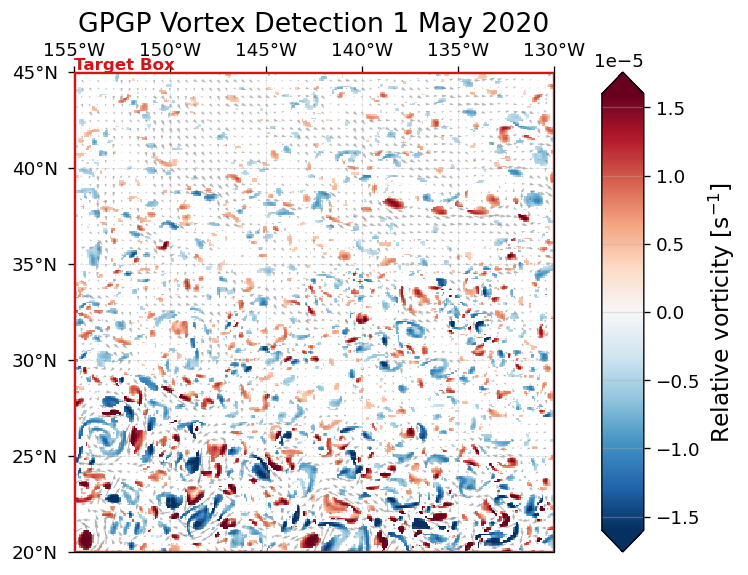

In [17]:
# ============================================================
# SETTINGS
# ============================================================

NB_DIR = Path.cwd()

case_name = "run_may1_test"  # edit

# Fixed symmetric colorbar magnitude
VORT_ABS_MAX = 1.6e-5

# Fixed target plotting domain
MAP_EXTENT = [-155, -130, 20, 45]

SAVE_JSON = True

# Store JSON directly inside processed folder
JSON_OUTPUT_DIR = Path("../data/processed")
JSON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. LOAD DATA
# ============================================================

title = "GPGP Vortex Detection 1 May 2020"

surface_ds = oa.process_glorys_data(
    "../data/input/GPGP_may2020.nc",
    averaging_period="1D",
)


# ============================================================
# 2. SELECT TARGET DOMAIN
# ============================================================

lat_s = 20
lat_n = 45
lon_w = -155
lon_e = -130

# center_lat = 30
# center_lon = -151.9

# dlat = 192 / 111.32          # ≈ 1.725 deg
# dlon = 192 / (111.32 * np.cos(np.deg2rad(center_lat)))   # ≈ 1.903 deg

# lat_s = center_lat - dlat/2
# lat_n = center_lat + dlat/2
# lon_w = center_lon - dlon/2
# lon_e = center_lon + dlon/2

print(f"Red box lat range: {lat_s:.2f} to {lat_n:.2f}")
print(f"Red box lon range: {lon_w:.2f} to {lon_e:.2f}")

les_box = oa.get_subdomain(
    lat_min=lat_s,
    lon_min=lon_w,
    lat_max=lat_n,
    lon_max=lon_e,
)

alpha = 0.2


# ============================================================
# 3. COMPUTE OW + EDDY MASK
# ============================================================

ow_results = oa.calculate_okubo_weiss(surface_ds)

signed_intensity, eddy_mask = oa.get_eddy_intensity(
    ow_results,
    alpha=alpha,
)


# ============================================================
# VISUALIZE
# ============================================================

fig, ax = oa.plot_eddy_intensity(
    intensity_data=signed_intensity,
    u=surface_ds.uo,
    v=surface_ds.vo,
    title=title,
    target_box=les_box,
    extent=None,
    vabs=VORT_ABS_MAX,
)

     label      polarity  n_cells    R_eq_km    R_max_km  Utheta_max_m_s  \
0      208  anticyclonic      320  85.885208  102.883322        0.211176   
1       40  anticyclonic      243  74.842196   55.281167        0.262683   
2       71      cyclonic      215  70.398372   30.799288        0.138741   
3      165  anticyclonic      207  69.076219   21.586318        0.149796   
4        7  anticyclonic      179  64.234729   13.382235        0.096373   
..     ...           ...      ...        ...         ...             ...   
586   1064  anticyclonic        8  13.579644   12.730916        0.027149   
587    937      cyclonic        8  13.579644   12.730916        0.037583   
588    916  anticyclonic        8  13.579644   12.730916        0.027705   
589    448  anticyclonic        8  13.579644   12.730916        0.051545   
590   1081  anticyclonic        8  13.579644   12.730916        0.031055   

     T_eddy_days  
0      35.429705  
1      15.304244  
2      16.143681  
3      10.4

c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


,eddy_id,label,polarity,R_eq_km,R_max_km,Utheta_max_m_s,T_eddy_days
0,1,208,anticyclonic,85.885208,102.883322,0.211176,35.429705
1,2,40,anticyclonic,74.842196,55.281167,0.262683,15.304244
2,3,71,cyclonic,70.398372,30.799288,0.138741,16.143681
3,4,165,anticyclonic,69.076219,21.586318,0.149796,10.479622
4,5,7,anticyclonic,64.234729,13.382235,0.096373,10.098044
...,...,...,...,...,...,...,...
586,587,1064,anticyclonic,13.579644,12.730916,0.027149,34.101521
587,588,937,cyclonic,13.579644,12.730916,0.037583,24.634099
588,589,916,anticyclonic,13.579644,12.730916,0.027705,33.417343
589,590,448,anticyclonic,13.579644,12.730916,0.051545,17.961493


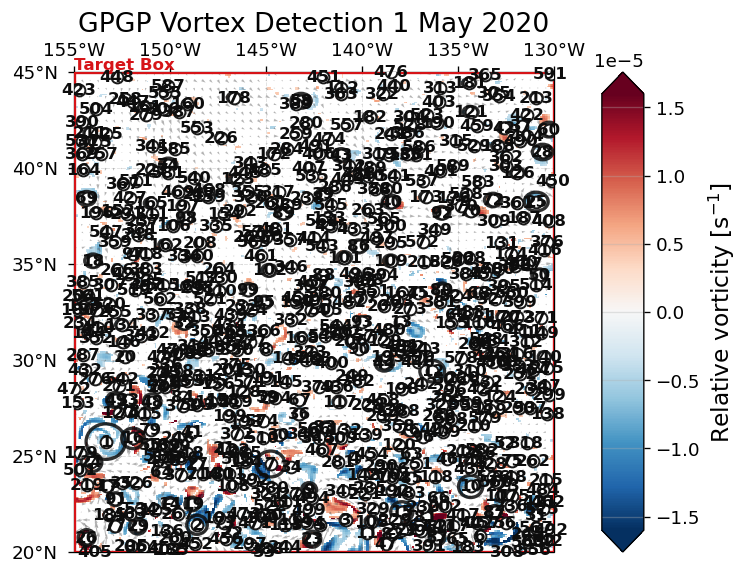

In [18]:

# ============================================================
# 4. ESTIMATE EDDY TURNOVER TIMES
# ============================================================

eddy_table, eddy_profiles, eddy_labels = oa.calculate_eddy_turnover_from_ow(
    surface_ds=surface_ds,
    ow_results=ow_results,
    eddy_mask=eddy_mask,
    alpha=alpha,
    target_box=les_box,
    min_cells=8,
    search_radius_factor=1.25,
    remove_mean=False,
)

print(eddy_table[[
    "label",
    "polarity",
    "n_cells",
    "R_eq_km",
    "R_max_km",
    "Utheta_max_m_s",
    "T_eddy_days",
]])

# ============================================================
# 5. SAVE JSON
# ============================================================

if SAVE_JSON:
    json_path = JSON_OUTPUT_DIR / f"ETT_{case_name}.json"

    # ------------------------------------------------------------
    # GLORYS source/time metadata
    # ------------------------------------------------------------
    source_file = surface_ds.attrs.get("source_file", "")
    source_stem = surface_ds.attrs.get("source_stem", "surface_ds")
    averaging_period = surface_ds.attrs.get("averaging_period", "")
    time_idx = surface_ds.attrs.get("time_idx", None)

    glorys_time_value = None
    glorys_day = None

    if "time" in surface_ds.coords:
        time_val = surface_ds["time"].values

        # Convert numpy datetime64 to clean string
        if np.issubdtype(np.asarray(time_val).dtype, np.datetime64):
            glorys_time_value = str(np.datetime_as_string(time_val, unit="D"))
            glorys_day = glorys_time_value
        else:
            glorys_time_value = str(time_val)
            glorys_day = str(time_val)

    # ------------------------------------------------------------
    # ETT summary statistics
    # ------------------------------------------------------------
    valid = eddy_table.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["R_max_km", "Utheta_max_m_s", "T_eddy_days"]
    )

    if len(valid) == 0:
        radius_summary = {
            "mean_R_max_km": None,
            "median_R_max_km": None,
        }
        velocity_summary = {
            "mean_Utheta_max_m_s": None,
            "median_Utheta_max_m_s": None,
        }
        ett_summary_json = {
            "mean_T_eddy_days": None,
            "0.5*mean_T_eddy_days": None,
            "median_T_eddy_days": None,
        }

    else:
        radius_summary = {
            "mean_R_max_km": float(valid["R_max_km"].mean()),
            "median_R_max_km": float(valid["R_max_km"].median()),
        }
        velocity_summary = {
            "mean_Utheta_max_m_s": float(valid["Utheta_max_m_s"].mean()),
            "median_Utheta_max_m_s": float(valid["Utheta_max_m_s"].median()),
        }
        ett_summary_json = {
            "mean_T_eddy_days": float(valid["T_eddy_days"].mean()),
            "0.5*mean_T_eddy_days": float(0.5 * valid["T_eddy_days"].mean()),
            "median_T_eddy_days": float(valid["T_eddy_days"].median()),
        }

    ett_json = {
        "case_name": case_name,

        "glorys_input": {
            "source_file": source_file,
            "source_stem": source_stem,
            "averaging_period": averaging_period,
            "time_index_after_resampling": None if time_idx is None else int(time_idx),
            "time_value": glorys_time_value,
            "day": glorys_day,
        },

        "target_box": {
            "lat_s": float(lat_s),
            "lat_n": float(lat_n),
            "lon_w": float(lon_w),
            "lon_e": float(lon_e),
        },

        "method": {
            "description": (
                "OW-detected eddies. Eddy centre is max absolute vorticity "
                "inside each OW core. Azimuthal velocity is radially averaged "
                "around the centre. ETT is T = 2*pi*R_max/Utheta_max."
            ),
            "alpha": float(alpha),
            "min_cells": 8,
            "search_radius_factor": 1.25,
            "remove_mean_velocity": True,
        },

        "n_eddies_used": int(len(valid)),

        "eddy_radius_km": radius_summary,

        "characteristic_velocity_m_s": velocity_summary,

        "eddy_turnover_time_days": ett_summary_json,
    }

    with open(json_path, "w") as f:
        json.dump(ett_json, f, indent=2)

    print(f"Saved ETT JSON to: {json_path}")


# ============================================================
# 6. VISUALIZE
# ============================================================

fig, ax, ett_summary = oa.plot_eddy_turnover_map(
    signed_intensity=signed_intensity,
    eddy_table=eddy_table,
    u=surface_ds.uo,
    v=surface_ds.vo,
    title=title,
    target_box=les_box,
    extent=les_box,
    vabs=VORT_ABS_MAX,
    show_radii=True,
)

ett_summary

In [19]:
# # ============================================================
# # SETTINGS
# # ============================================================

# INPUT_FILE = "../data/input/GPGP_2020.nc"

# START_DATE = "2020-01-01"
# END_DATE = "2020-12-31"
# frames_dir = (
#     rf"C:\Users\Jelle Gortemaker\Downloads\gif_frames_"
#     rf"{START_DATE}_to_{END_DATE}"
# )
# os.makedirs(frames_dir, exist_ok=True)

# MAP_EXTENT = [-155, -130, 20, 45]

# # Colorbar setting
# # Option 1: fixed manual value
# # VORT_ABS_MAX = 8e-6

# # Option 2: automatically determine fixed range from detected vortex-core values
# VORT_PERCENTILE = 98


# # ============================================================
# # DAILY TIME RANGES
# # ============================================================

# dates = pd.date_range(start=START_DATE, end=END_DATE, freq="D")

# time_ranges = [
#     (date.strftime("%Y-%m-%d"), date.strftime("%Y-%m-%d"))
#     for date in dates
# ]

# print(f"Number of daily frames: {len(time_ranges)}")
# print(f"First day: {time_ranges[0][0]}")
# print(f"Last day : {time_ranges[-1][0]}")


# # ============================================================
# # LOAD DAILY DATA
# # ============================================================

# surface_datasets = []
# ow_results = []
# signed_vort_list = []
# mask_list = []

# for tr in time_ranges:
#     surface_ds = oa.process_glorys_data(
#         INPUT_FILE,
#         averaging_period="1D",
#         time_range=tr,
#     )

#     results = oa.calculate_okubo_weiss(surface_ds)
#     signed_vort, mask = oa.get_eddy_intensity(results, alpha=0.2)

#     surface_datasets.append(surface_ds)
#     ow_results.append(results)
#     signed_vort_list.append(signed_vort)
#     mask_list.append(mask)


# # ============================================================
# # SHARED COLORBAR RANGE BASED ON DETECTED VORTEX CORES
# # ============================================================

# vortex_values = np.concatenate([
#     np.ravel(da.values[np.isfinite(da.values)])
#     for da in signed_vort_list
# ])

# if vortex_values.size == 0:
#     raise ValueError("No detected vortex-core values found. Check the OW threshold or input data.")

# VORT_ABS_MAX = np.nanpercentile(np.abs(vortex_values), VORT_PERCENTILE)
# VORT_ABS_MAX = np.ceil(VORT_ABS_MAX / 1e-6) * 1e-6

# print(f"Shared vortex-core colorbar range: ±{VORT_ABS_MAX:.2e} s^-1")


# # ============================================================
# # INTERACTIVE VIEWER
# # ============================================================

# def show_frame(i):
#     fig, ax = oa.plot_eddy_intensity(
#         signed_vort_list[i],
#         u=surface_datasets[i].uo,
#         v=surface_datasets[i].vo,
#         title=f"GPGP Vortex Detection {time_ranges[i][0]}",
#         extent=MAP_EXTENT,
#         vabs=VORT_ABS_MAX,
#     )
#     plt.show()


# widgets.interact(
#     show_frame,
#     i=widgets.IntSlider(
#         min=0,
#         max=len(time_ranges) - 1,
#         step=1,
#         value=0,
#         description="Day index",
#     ),
# )


# # ============================================================
# # SAVE FRAMES FOR GIF
# # ============================================================

# for i, tr in enumerate(time_ranges):
#     fig, ax = oa.plot_eddy_intensity(
#         signed_vort_list[i],
#         u=surface_datasets[i].uo,
#         v=surface_datasets[i].vo,
#         title=f"GPGP Vortex Detection {tr[0]}",
#         extent=MAP_EXTENT,
#         vabs=VORT_ABS_MAX,
#     )

#     frame_path = os.path.join(frames_dir, f"frame_{i:02d}_{tr[0]}.png")

#     fig.savefig(
#         frame_path,
#         dpi=150,
#         facecolor="white",
#         bbox_inches="tight",
#     )
#     plt.close(fig)

# print(f"Frames saved in: {frames_dir}")